# Principal Component Analysis and Non-Negative Matrix Factorization


This notebook aims to introduce dimensionality reduction with Principle Component Analysis (PCA) and Non-negative Matrix Factorization (NMF).

As discussed in the lecture the two techniques differ in the constraints they impose on the dictionary elements and the representations, which in-turn leads to a completely different objective function and the optimization algorithm.

**Discussion**
1. Why might we want to reduce the dimensionality of a dataset?
2. Can you explain PCA and NMF? What are the differences?

## Principal Component Analysis (PCA)

PCA is essentially a projection method, which involves computing the projections of the original input into a smaller dimension representation such that the error between the original vector and the reconstructed is minimized.


$$
\arg \min_{W,Z} \| X - WZ \|^2_F
$$


This method is mathematically equivalent to maximizing the variance of the projected data and can be efficiently computed by decomposing the data matrix $X$ into its singular values.

**Discussion**
1. Why does maximizing variance lead to a good low-dimensional representation?

### Load the dataset

We will first load the standard packages and then load and use the black-white faces data set, which is available to download from here:
https://github.com/HyTruongSon/Pattern-Classification/tree/master/MIT-CBCL-database

We have the files already in the folder distributed in the link: https://drive.google.com/drive/folders/1giVtcN6X03O26Q3j7zUMqjuAc5FR1cAI?usp=share_link

Load the standard packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy import linalg
from scipy.sparse import diags
import scipy.optimize

import autograd
from autograd import grad
import autograd.numpy as numpy
import autograd.numpy.random as npr

%matplotlib inline

from google.colab import drive
drive.mount('/content/gdrive/')
import sys
sys.path.append('/content/gdrive/MyDrive/ML473/recitation/lab12')

# the normalize function which first computes the mean
# and then subtracts it from all the data points
def normalize(data):
    mean = np.mean(data, axis=1)[:,None]
    return data - mean

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


Load the dataset and display a test image

Input data shape: (2429, 361)


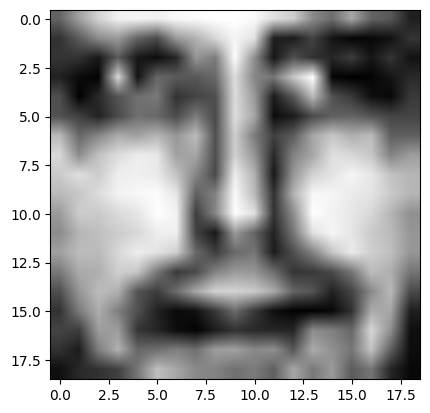

In [3]:
raw_data = open('/content/gdrive/MyDrive/ML473/recitation/lab12/data/svm.train.normgrey').readlines()
X = []

for line in raw_data[2:]:
    if line.strip() == "":
        continue
    if int(line.split()[-1]) == -1:
        # not face, skip
        continue
    else:
        X.append( [float(yy) for yy in line.split()[:-1]] )

X = np.array(X)
print('Input data shape: {}'.format(X.shape))

plt.imshow(X[0].reshape((19, 19)), cmap=cm.gray, interpolation="bilinear")

X = normalize(X)
X = np.transpose(X)

**Discussion**
1. Why do we normalize the data before applying PCA?
2. Why do we take the transpose of the data before applying PCA?

Get the size of the original input space and also set the size of the new low-dimensional output space

In [4]:
n_comp = 121  # how many dimensions will be in the new space

(d, N) = X.shape
q = n_comp

print ("d: ",  d)
print ("N: ", N)
print ("q: ", q)

d:  361
N:  2429
q:  121


**Discussion**
1. What does the shape of does the shape of
X tell us? What is d? What is N? What is q?
2. What might PCA mistakenly capture if we skip normalization?

### Compute the Principal Components

We use the Singular Value Decomposition of the matrix X to compute all the components.

In [5]:
def train_pca_svd(input_data):
    U, S, V = linalg.svd(X)  # SVD decomposition
    print('Input dimensions: {}'.format(input_data.shape))
    print('Left singular vector matrix shape: {}'.format(U.shape))
    print('Right singular vector matrix shape: {}'.format(V.shape))
    print('Singular value matrix shape: {}'.format(S.shape))

    return S, U

In [6]:
S_faces, U_faces = train_pca_svd(X)

Input dimensions: (361, 2429)
Left singular vector matrix shape: (361, 361)
Right singular vector matrix shape: (2429, 2429)
Singular value matrix shape: (361,)


In order to compute the principal components, we take the most impactful columns of the left singular matrix

In [7]:
# take q most impactful columns from U. These are your principal components
top_vectors = U_faces[:, :q]

# reduce dimensionality of our input data by projecting each point onto the principal components
X_reduced = X.transpose() @ top_vectors

In [8]:
# lets check the shape of the old and the new data matrix
np.transpose(X).shape, X_reduced.shape

((2429, 361), (2429, 121))

**Discussion**


1.   Why use SVD to compute PCA?
2.   What do U, S, and V represent? You can check the documentation of linalg.svd to answer.
3.   Why use the left singular vectors U?
4. Why would directions with larger singular values matter more?
5. Why does keeping only the top directions reduce noise?



### Visualization of principle components

We now project each face onto the principal components and reconstruct it.

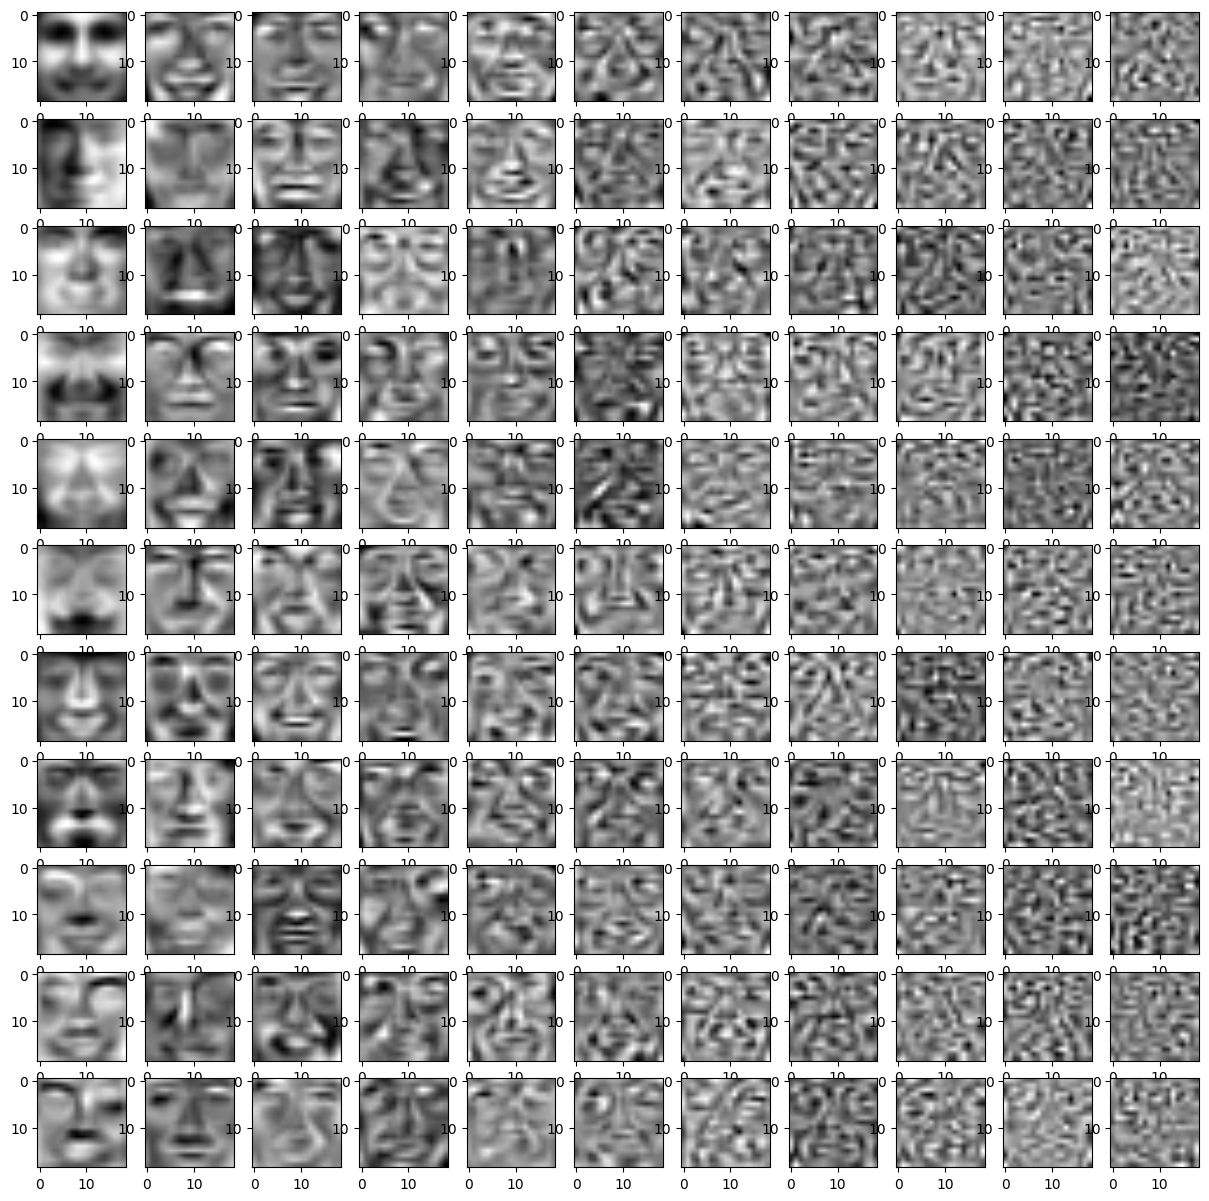

In [9]:
loadings = top_vectors.transpose()
f, axarr = plt.subplots(int(np.sqrt(n_comp)), int(np.sqrt(n_comp)), figsize = (15, 15))

comp_ix = 0
# loop over the principal components and display them as an image of size 19x19
for j in range(int(np.sqrt(n_comp))):
    for i in range(int(np.sqrt(n_comp))):
        axarr[i, j].imshow(loadings[comp_ix].reshape((19, 19)), cmap=cm.gray, interpolation="bilinear")
        comp_ix += 1

In [10]:
# compute the reconstruction error between the original and reconstructed image
reconstruction_err = np.linalg.norm( X - top_vectors @ np.transpose(X_reduced) )
print ('Reconstructions error: ', reconstruction_err)

Reconstructions error:  38.38769195134055


# Reconstruct the image back from the reduced space

In [11]:
def reconstruct_face(idx):
    original_face = X[:,idx]
    reduced_face = X_reduced[idx]
    reconstructed_face = reduced_face @ loadings

    plt.figure(figsize=(10, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(original_face.reshape((19, 19)), cmap=cm.gray, interpolation="bilinear")

    plt.subplot(1, 3, 3)
    plt.imshow(reconstructed_face.reshape((19, 19)), cmap=cm.gray, interpolation="bilinear")

In [12]:
loadings.shape

(121, 361)

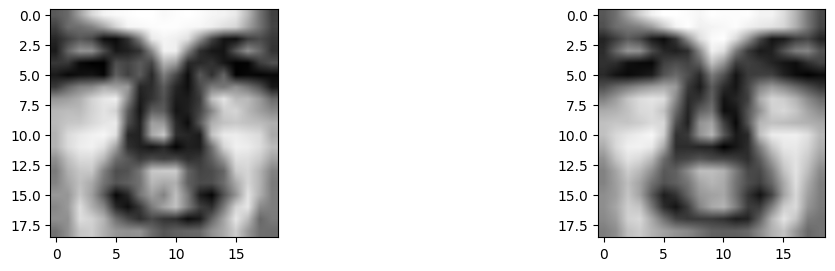

In [13]:
# the reconstructed face does not look that bad
reconstruct_face(20)

**Discussion**
1. When reconstructing, why does adding more components improve the image?
2. Why do PCA components look like ghost faces instead of real faces?

## Exercise 1

1. Repeat the dimensionality reduction with PCA with target dimension size of 200, 100 and 50.
2. Plot the reconstructed images using the reduced dimensions.
3. Compute the reconstruction error and plot it with the dimension on the x axis and the reconstruction error on the y axis.
4. Comment on how the results are affected as the dimension changes.

In [14]:
# TODO
# dims we want to try
dims = [200, 100, 50]

recon_errors = {}

def reconstruct_with_q(q):
    """
    Use the first q singular vectors (columns of U_faces) to
    reconstruct all faces and compute reconstruction error.
    """
    # principal components (basis vectors) 361 × q
    U_q = U_faces[:, :q]

    # project data to reduced space:  (2429 × 361) · (361 × q) = 2429 × q
    Z = X.T @ U_q

    # reconstruct in original space:  (2429 × q) · (q × 361) = 2429 × 361
    X_hat = (Z @ U_q.T).T       # -> 361 × 2429 to match X

    # mean squared reconstruction error over all pixels & all images
    mse = np.mean((X - X_hat) ** 2)
    return X_hat, mse


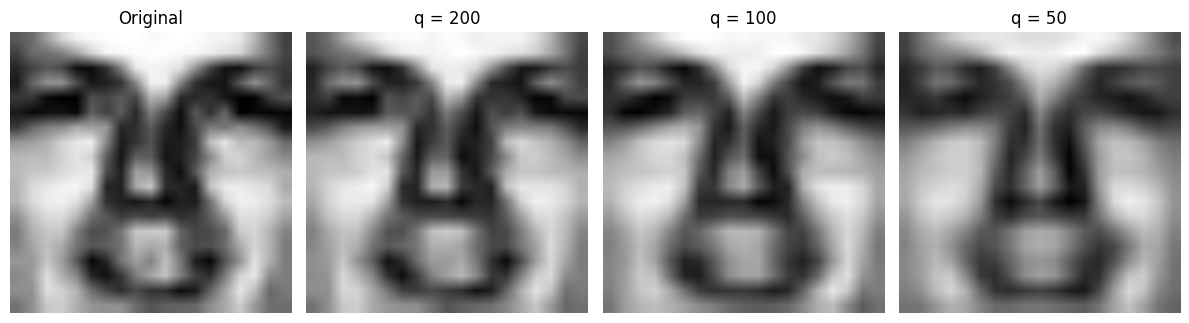

In [15]:
idx = 20  # choose any face index you like

plt.figure(figsize=(12, 4))

# original
plt.subplot(1, len(dims) + 1, 1)
plt.title("Original")
plt.imshow(X[:, idx].reshape(19, 19), cmap=cm.gray, interpolation='bilinear')
plt.axis('off')

for i, q in enumerate(dims, start=2):
    X_hat_q, mse_q = reconstruct_with_q(q)
    recon_errors[q] = mse_q

    plt.subplot(1, len(dims) + 1, i)
    plt.title(f"q = {q}")
    plt.imshow(X_hat_q[:, idx].reshape(19, 19), cmap=cm.gray, interpolation='bilinear')
    plt.axis('off')

plt.tight_layout()
plt.show()


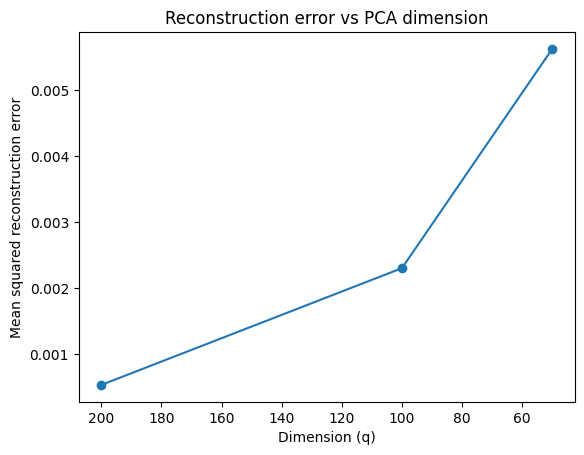

In [16]:
# make sure errors are computed
for q in dims:
    if q not in recon_errors:
        _, recon_errors[q] = reconstruct_with_q(q)

plt.figure()
plt.plot(dims, [recon_errors[q] for q in dims], marker='o')
plt.gca().invert_xaxis()  # optional: so 200→100→50 left→right to show error increasing
plt.xlabel("Dimension (q)")
plt.ylabel("Mean squared reconstruction error")
plt.title("Reconstruction error vs PCA dimension")
plt.show()


## Non-Negative Matrix Factorization (NMF)
The optimization problem for non-negative matrix factorization is similar to the PCA, except it has additional non-negativity constraints on $W$ and $Z$.

$$
\begin{align}
\arg \min_{W,Z} & \| X - WZ \|^2_F \\
s.t. \quad & w_{ij} \ge 0 \quad i = 1, \ldots, n \quad j = 1, \ldots, p \\
           & z_{ij} \ge 0 \quad i = 1, \ldots, p \quad j = 1, \ldots, n \\
\end{align}
$$

Presence of additional constraints makes the optimization problem a little harder.

**Discussion**
1. Given that NMF is only non-negative (additive), can you think of an intuitive way to explain it?
2. So when would NMF be appropriate to use?  

In [17]:
def train_nmf(input_data):
    multiplicative = True
    maxiter = 1000
    X = input_data
    W = np.real( (np.random.rand(d,q))*0.5 )
    Z = np.real( (np.random.rand(q,N))*0.5 )
    print ('start optimising...')
    # X : (d, N)
    # W : (d, q)
    # Z : (q, N)
    for u_iter in range(maxiter):
        if multiplicative:
            diff = X - W @ Z
            W = W * (X @ np.transpose(Z)) / (W @ Z @ np.transpose(Z))
            Z = Z * (np.transpose(W) @ X) / (np.transpose(W) @ W @ Z)
        else:
            diff = X - W @ Z
            lr = 0.001
            W_ = W + lr * (diff) @ np.transpose(Z)
            Z_ = Z + lr * np.transpose(W) @ (diff)
            W, Z = np.maximum(W_, 0, W_), np.maximum(Z_, 0, Z_)

        if u_iter % 100 == 0:
            print (autograd.numpy.linalg.norm(diff))

    print ('optimization finished')
    return W, Z

In [18]:
X = X - np.min(X)  # why do we do that?

loadings, X_reduced = train_nmf(X)

start optimising...
2489.4445023518438
106.91641218872302
95.09308308700886
91.5323126342984
89.74497399091346
88.63784541813922
87.85263866586374
87.2623934073539
86.80842620266964
86.44762329958913
optimization finished


In [19]:
loadings = loadings.transpose()

IndexError: index 50 is out of bounds for axis 0 with size 50

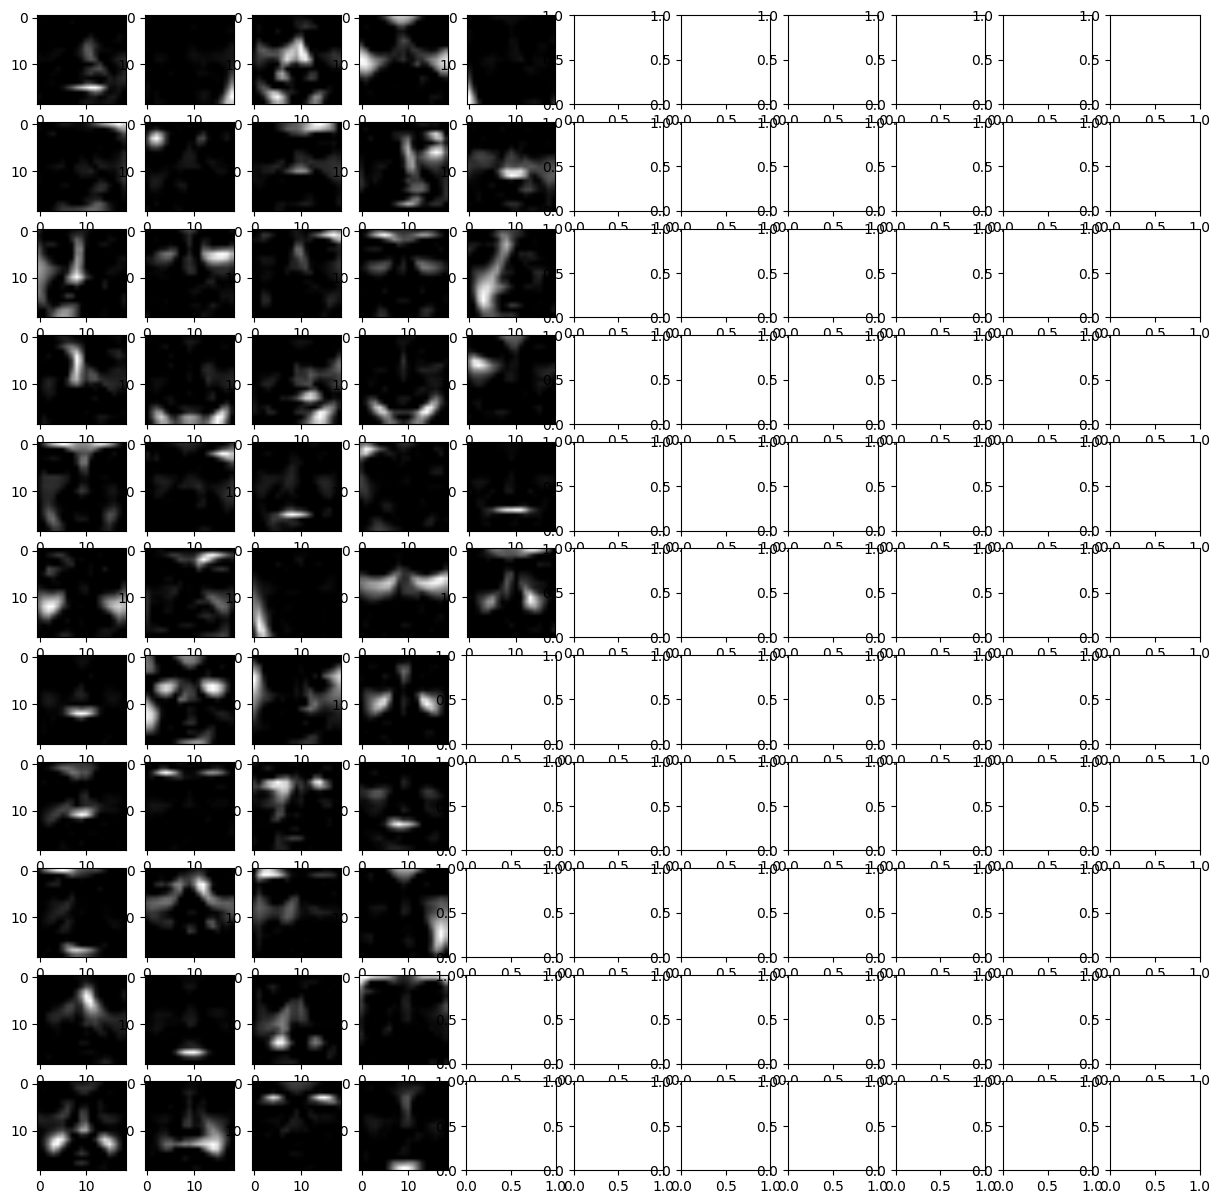

In [20]:
# visualize the factorization learnt
f, axarr = plt.subplots(int(np.sqrt(n_comp)), int(np.sqrt(n_comp)), figsize = (15, 15))

comp_ix = 0
for j in range(int(np.sqrt(n_comp))):
    for i in range(int(np.sqrt(n_comp))):
        axarr[i, j].imshow(loadings[comp_ix].reshape((19, 19)), cmap=cm.gray, interpolation="bilinear")
        comp_ix += 1

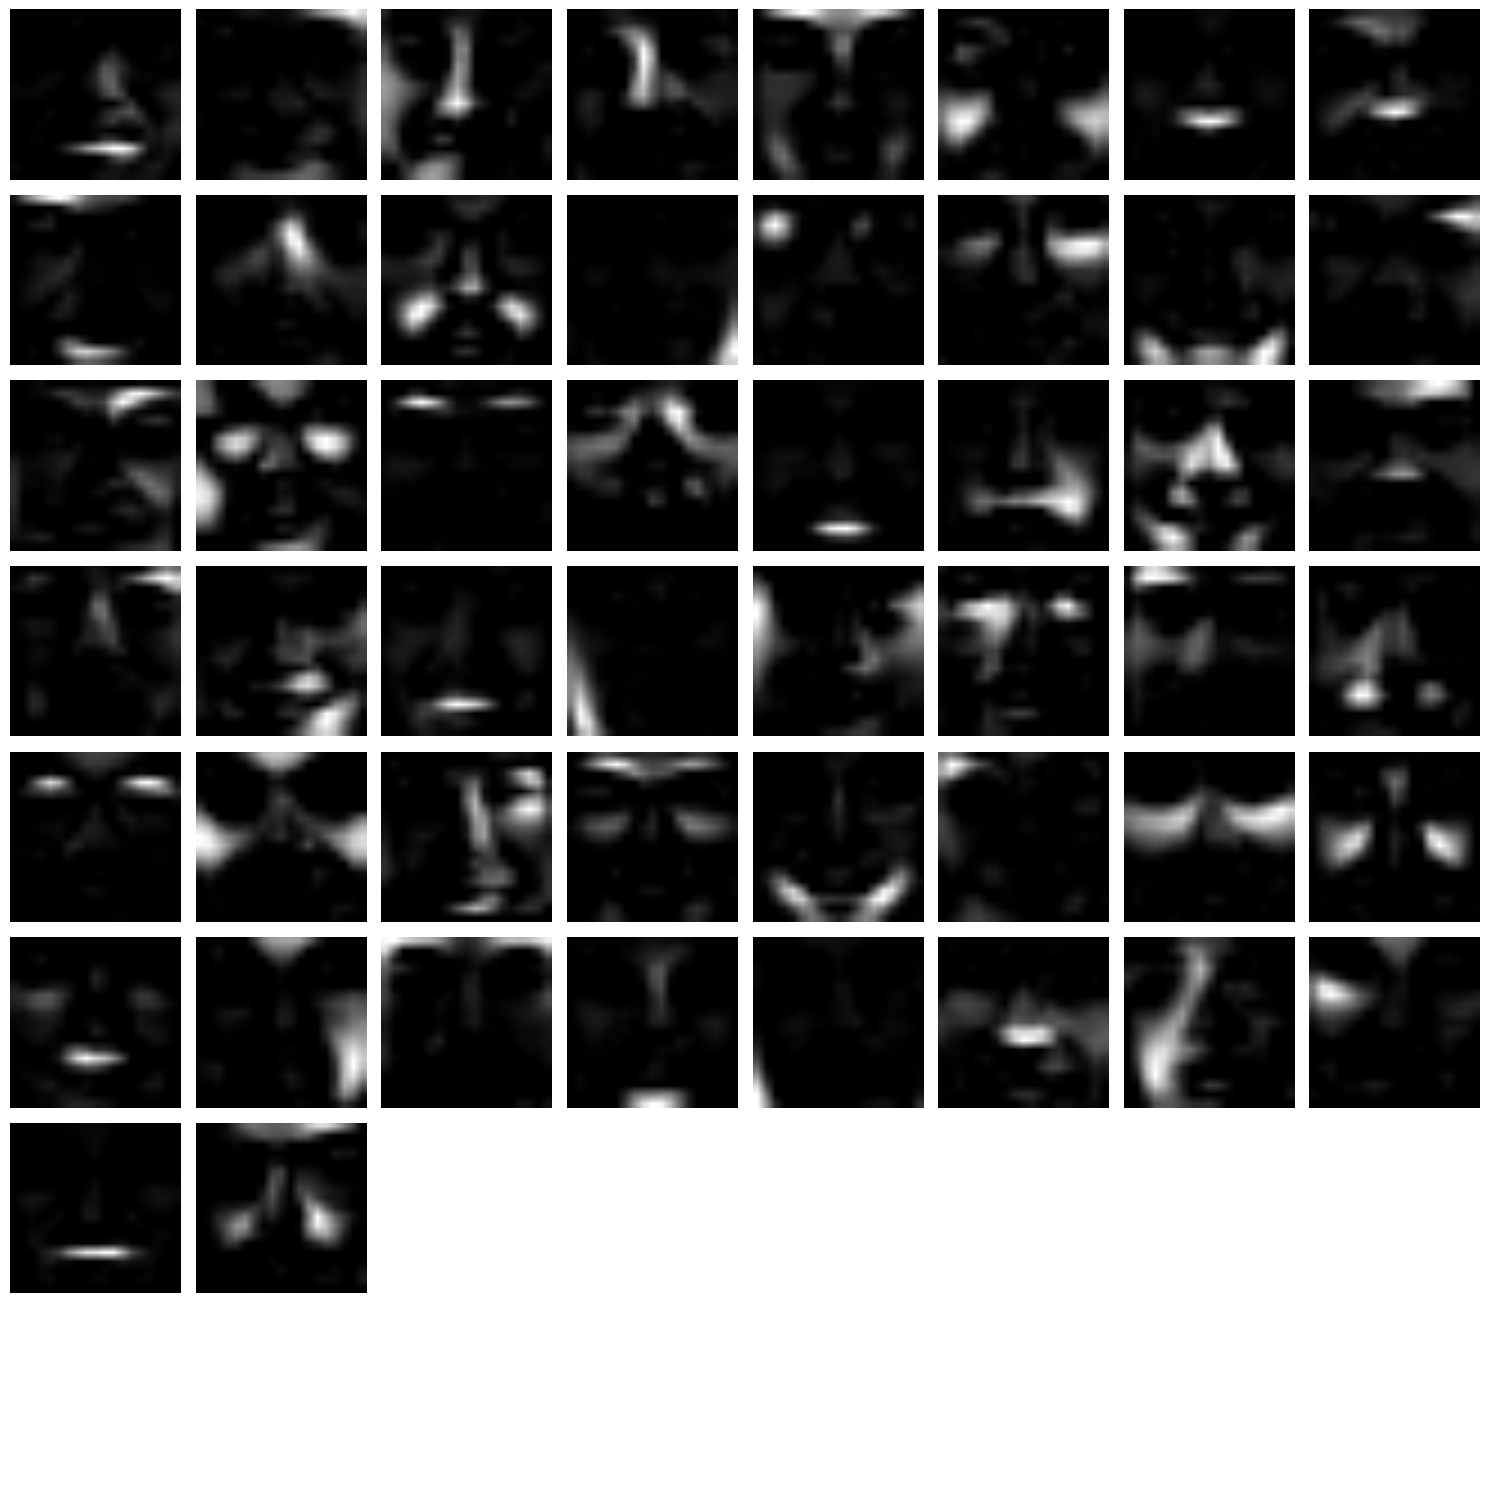

In [21]:
n_comp = loadings.shape[0]                # = 50
grid = int(np.ceil(np.sqrt(n_comp)))      # smallest square grid that fits all comps

fig, axarr = plt.subplots(grid, grid, figsize=(15, 15))

comp_ix = 0
for i in range(grid):
    for j in range(grid):
        if comp_ix < n_comp:
            axarr[i, j].imshow(loadings[comp_ix].reshape((19, 19)),
                               cmap=cm.gray, interpolation="bilinear")
            axarr[i, j].axis("off")
            comp_ix += 1
        else:
            axarr[i, j].axis("off")       # hide empty cells

plt.tight_layout()
plt.show()


**Discussion**
1. Which facial regions appear consistently as components?
2. Why might NMF be more interpretable than PCA for faces?
3.How would you describe each NMF component in plain language?
4. When would you prefer PCA over NMF?

## Optional: Featurizing text data and reducing its dimensionality

We will now see a second example of dimensionality reduction on text data. In this data set, each document will be a training sample and it will be represented as a tf-idf vector. Tf-idf which is an abbreviation of **Term Frequency Inverse Document Frequency** and its definition is provided here: https://en.wikipedia.org/wiki/Tf%E2%80%93idf  

In [22]:
from sklearn import datasets
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

newsgroups_train= datasets.fetch_20newsgroups(subset='train',
                                               categories=['comp.sys.mac.hardware', 'rec.motorcycles', 'sci.med', 'soc.religion.christian'])
tfidf_vectorizer = TfidfVectorizer(min_df=30)
X = tfidf_vectorizer.fit_transform(newsgroups_train.data).toarray()
y = newsgroups_train.target

In [23]:
print(X[0][0:100])
print(y)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.06961504 0.         0.
 0.         0.         0.         0.         0.07296304 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.0963884  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[2 2 0 ...

In [24]:
X = np.transpose(X)

(d, N) = X.shape
q = 5  # our reduced dimension

print ("d: old dim",  d)
print ("N: num of samples", N)
print ("q: new dim", q)

d: old dim 1771
N: num of samples 2369
q: new dim 5


In [25]:
S_text, V_text = train_pca_svd(X)

Input dimensions: (1771, 2369)
Left singular vector matrix shape: (1771, 1771)
Right singular vector matrix shape: (2369, 2369)
Singular value matrix shape: (1771,)


In [26]:
# take q most impactful columns from V
top_vectors = V_text[:, :q]

# reduce dimensionality of our input data
X_reduced = X.transpose() @ top_vectors

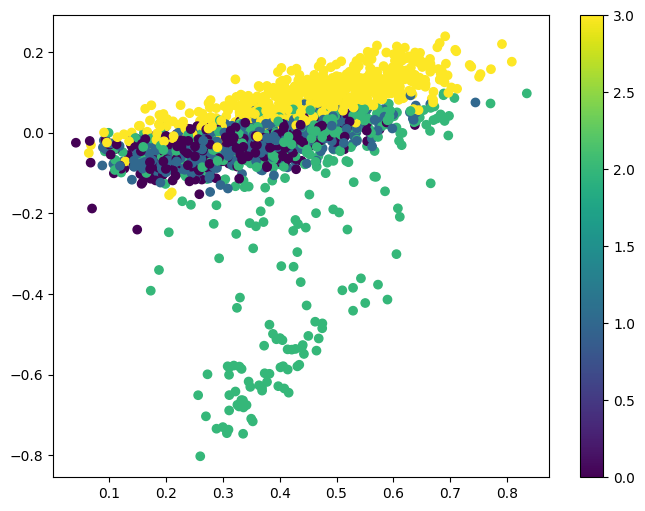

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:,0], X_reduced[:, 1], c = y)
plt.colorbar()

In [28]:
loadings = top_vectors.transpose()
invocab = dict([(vv,kk) for kk, vv in tfidf_vectorizer.vocabulary_.items()])
insens_idx = np.argsort(loadings[0])

print ('Top 10 most activated words (loadings)')
for jj in insens_idx[-10:]:
    print ('{} ({:0.6f})'.format(invocab[jj], loadings[0,jj]))


print ('\n Top 10 least activated words (loadings)')
for jj in insens_idx[:10]:
    print ('{} ({:0.6f})'.format(invocab[jj], loadings[0,jj]))

Top 10 most activated words (loadings)
for (0.114492)
you (0.132383)
it (0.160184)
that (0.178339)
in (0.184909)
is (0.189900)
and (0.206761)
of (0.255349)
to (0.266096)
the (0.472707)

 Top 10 least activated words (loadings)
58 (0.002314)
reduce (0.002355)
mon (0.002376)
despite (0.002425)
toward (0.002450)
51 (0.002455)
developed (0.002462)
argue (0.002472)
typical (0.002473)
1st (0.002503)


In [29]:
reconstruction_err = np.linalg.norm( X - top_vectors @ np.transpose(X_reduced) )
print ('Reconstructions error: ', reconstruction_err)

Reconstructions error:  43.35201754483636


## (Optional) Exercise 2

Let's try to analyze what kind of features are being learnt as a result of the dimensionality reduction objective.
1. Repeat the extraction of top 10 words for all 5 dimensions in the reduced vectors.
2. Comment on the result.

In [ ]:
# TODO

In [30]:
# loadings: shape (q, vocab_size)  (already defined as top_vectors.T)
# tfidf_vectorizer: already fitted
# q = 5

loadings = top_vectors.T               # (5, vocab_size)
invocab  = {v: k for k, v in tfidf_vectorizer.vocabulary_.items()}

for comp in range(loadings.shape[0]):
    comp_vec = loadings[comp]

    # indices of 10 words with largest absolute weight in this component
    top_idx = np.argsort(np.abs(comp_vec))[-10:][::-1]

    print(f"\nComponent {comp} – top 10 words:")
    for j in top_idx:
        word  = invocab[j]
        score = comp_vec[j]
        print(f"  {word:20s}  loading = {score: .4f}")



Component 0 – top 10 words:
  the                   loading =  0.4727
  to                    loading =  0.2661
  of                    loading =  0.2553
  and                   loading =  0.2068
  is                    loading =  0.1899
  in                    loading =  0.1849
  that                  loading =  0.1783
  it                    loading =  0.1602
  you                   loading =  0.1324
  for                   loading =  0.1145

Component 1 – top 10 words:
  pitt                  loading = -0.3720
  geb                   loading = -0.3411
  banks                 loading = -0.3394
  gordon                loading = -0.3345
  edu                   loading = -0.2246
  cs                    loading = -0.2179
  god                   loading =  0.1553
  dsl                   loading = -0.1166
  shameful              loading = -0.1166
  cadre                 loading = -0.1166

Component 2 – top 10 words:
  god                   loading = -0.2110
  com                   loading